## Decision Trees（決策樹）

決策樹是分類與迴歸任務中廣泛使用的機器學習模型。本質上，它透過學習一系列 **if/else** 問題的層級結構，最終得出預測與決策。

這些問題類似於你在「二十問（Twenty Questions）」遊戲中可能會問的問題。假設你想區分以下四種動物：**熊、鷹、企鵝與海豚**，目標是使用最少次 **if/else** 提問來找到正確答案：

1. 你可以先問：「這種動物有沒有羽毛？」這個問題能將可能的動物範圍縮小為兩組（有羽毛：鷹、企鵝；無羽毛：熊、海豚）。
2. 如果答案是「是」，你可以接著問：「這種動物是否會飛？」來區分**鷹與企鵝**。
3. 如果答案是「否」（無羽毛），剩餘選項為海豚與熊，此時你可以問：「這種動物是否有鰭？」來區分**海豚與熊**。

這一系列問答邏輯可以用決策樹來表示，如下列程式碼範例：

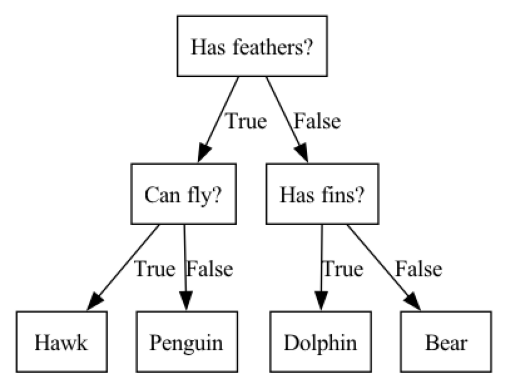

In [22]:
# 繪製「二十問」動物分類決策樹範例
import mglearn
import matplotlib.pyplot as plt

mglearn.plots.plot_animal_tree()
plt.show()

在這張決策樹圖中，每個**節點（Node）**代表一個判定問題，或是包含最終答案的**葉節點（Leaf Node，或稱終端節點）**；節點之間的**邊（Edge）**則連結了對問題的回答以及後續要引導的方向。

以機器學習的術語來說，我們建立了一個分類模型，利用「是否有羽毛」、「是否會飛」與「是否有鰭」這三個特徵（Features），來區分四種動物類別（鷹、企鵝、海豚與熊）。在實際應用中，我們無需人工手動設定這些問答規則，而是透過監督式學習（Supervised Learning）自動從資料中學習並建構出決策樹。

### 2.2.1 構建決策樹（Building Decision Trees）

讓我們逐步講解如何為二維分類資料集建立決策樹。此資料集包含兩個半月形（每個類別包含 50 個資料點，共 100 個資料點），我們稱此資料集為 `two_moons`。

學習決策樹意味著學習能夠最快找到正確答案的 **if/else** 問題序列。在機器學習中，這些問題被稱為**測試（Tests）**。通常，資料並非像動物範例那樣以二元（是/否）特徵的形式出現，而是以連續數值特徵的形式呈現（例如二維座標）。用於連續資料的測試形式為：**「特徵 $i$ 是否大於等於值 $a$？」**

/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

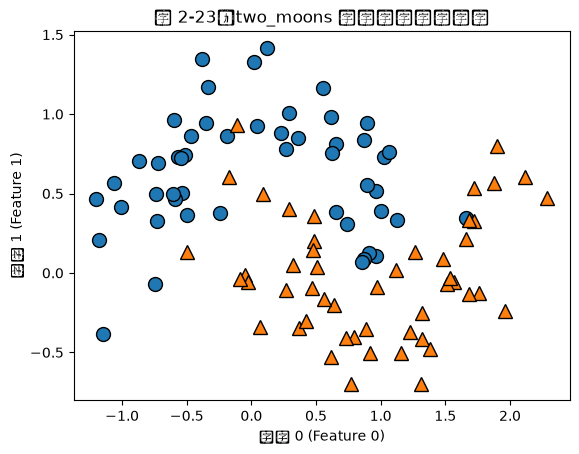

In [23]:
# 📌 標註：圖 2-23 —— two_moons 二維分類資料集散佈圖
from sklearn.datasets import make_moons
import mglearn
import matplotlib.pyplot as plt

# 產生 two_moons 資料集 (固定 random_state=3 以與書籍範例圖 2-23 一致)
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)

# 使用 mglearn 繪製散佈圖（藍色圓點代表類別 0，紅色三角形代表類別 1）
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.title("圖 2-23：two_moons 二維資料集散佈圖")
plt.xlabel("特徵 0 (Feature 0)")
plt.ylabel("特徵 1 (Feature 1)")
plt.show()

### 決策樹的漸進構建過程與「深度（Depth）」解析

在機器學習中，決策樹的**深度（Depth，或稱 `max_depth`）**指的是**決策樹最多可以連續提出幾層 if/else 問題（即空間分割的次數）**。

透過執行 `mglearn.plots.plot_tree_progressive()`，我們可以看到隨著決策樹深度從 1 逐步增加到 9，特徵空間的切分過程與樹狀結構的變化（📌 **對應圖 2-24、圖 2-25、圖 2-26**）：

---

#### 1. 深度 `depth = 1`（📌 圖 2-24：第一層切分）
* **區域分割（左圖）**：演算法搜尋所有可能的切割點，找到能獲得最大資訊量的測試條件——在 $X[1] = 0.0596$ 處劃出一條水平切分線，將資料集分割為上下兩個區域。
* **樹狀結構（右圖）**：最頂層的**根節點（Root Node）**包含全部 100 個資料點（類別 0 與類別 1 各 50 個，即 `counts = [50, 50]`）。
  * 條件成立（True，小於等於 0.0596，向下）：分至左節點（`counts = [2, 32]`）。
  * 條件不成立（False，大於 0.0596，向上）：分至右節點（`counts = [48, 18]`）。
* 此時樹的深度只有 1，雖然有了初步分類效果，但兩個區域內仍混雜著兩種不同類別的資料點。

---

#### 2. 深度 `depth = 2`（📌 圖 2-25：第二層切分）
* **區域分割與結構擴充**：為了提升分類精確度，演算法在上一層劃出的區域中繼續搜尋最佳切分條件（例如對特徵 $X[0]$ 進行縱向切割）。
* 特徵空間被進一步劃分為 4 個獨立區域，樹狀結構也隨之擴充到第 2 層（共包含 4 個葉節點）。

---

#### 3. 深度 `depth = 9`（📌 圖 2-26：完全樹與過擬合 Overfitting）
* **遞歸劃分終點**：若不限制樹的深度，遞歸切分過程會持續進行，直到劃分出的每個區域都只包含單一類別的資料點為止。
* **純葉節點（Pure Leaves）**：只包含單一目標類別的葉節點稱為「純葉節點」。在 `depth = 9` 時，所有葉節點皆為純葉節點。
* **過擬合現象（Overfitting）**：觀察邊界圖可以發現決策邊界變得極為曲折複雜，甚至為了包覆單一離群點而切割出狹小分區。這表示模型過度記憶了訓練資料的雜訊與細節，導致泛化能力下降。因此在實用上，通常會限制 `max_depth` 進行剪枝（Pruning）。

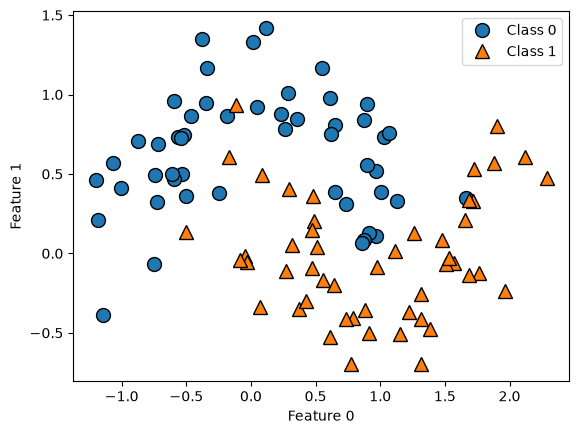

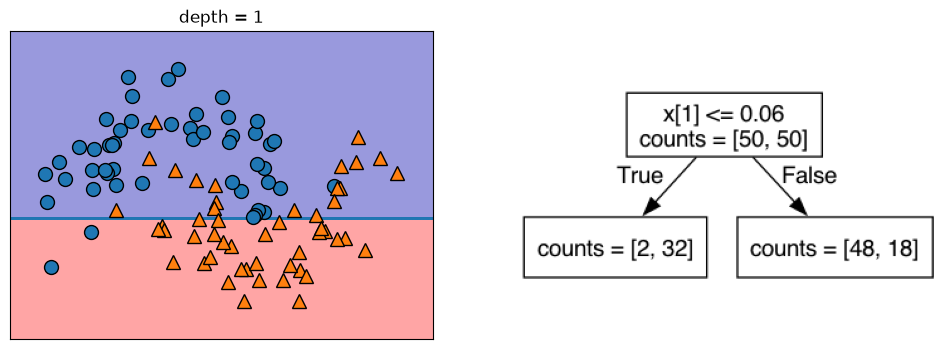

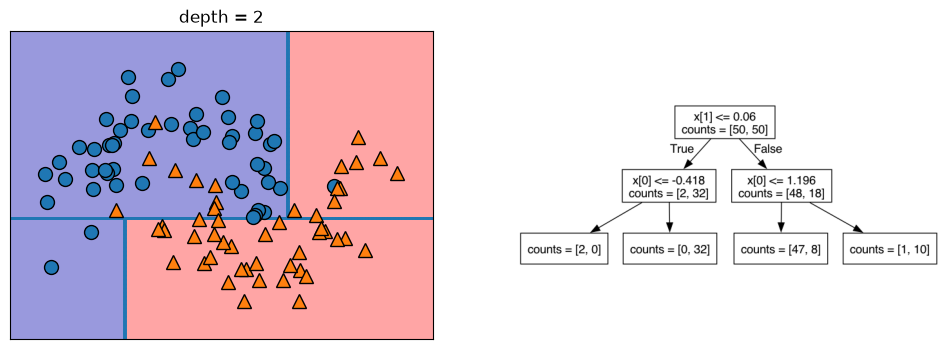

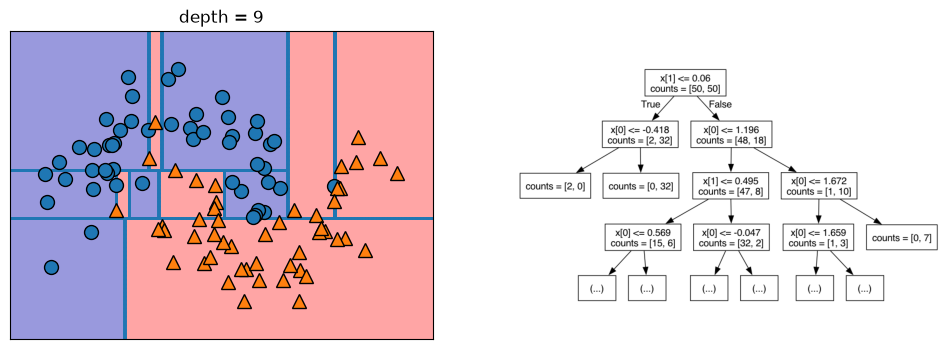

In [24]:
# 📌 標註：圖 2-24 ~ 圖 2-26 —— 決策邊界與相對應的樹狀圖 (depth=1, 2, 9 漸進構建過程)
import mglearn
import matplotlib.pyplot as plt

mglearn.plots.plot_tree_progressive()
plt.show()

### 2.2.2 控制決策樹的複雜性（Controlling Complexity of Decision Trees）

通常，如果讓決策樹持續分支直到所有葉節點都成為「純葉節點」，會導致模型結構過於複雜，並產生嚴重的**過擬合（Overfitting）**現象。純葉節點意味著決策樹在訓練集上的準確率高達 100%，因為每個訓練資料點都被完美地劃分到正確的類別區域中。

觀察圖 2-26（`depth = 9`，最右側圖）可以明顯看到過擬合的痕跡：例如在屬於類別 0 的點群中間包覆了一小塊類別 1 的區域；或者在最右側類別 0 的單一資料點周圍切割出狹長的小分區。這種決策邊界過度關注了遠離同類群體的**離群值（Outliers）**，並不符合直覺與實務需求。

為防止過擬合，機器學習中常見兩種**剪枝策略**：
1. **預先剪枝（Pre-pruning）**：在決策樹建構過程中提前停止分支。常見標準包括限制最大深度（`max_depth`）、限制最大葉節點數（`max_leaf_nodes`），或要求節點至少包含一定數量的樣本才允許分割（`min_samples_split`）。
2. **事後剪枝（Post-pruning，或稱剪枝）**：先讓決策樹完全生長，事後再移除或合併資訊量效益較低的節點。

在 `scikit-learn` 中，決策樹分別透過 `DecisionTreeClassifier` 與 `DecisionTreeRegressor` 類別實現。值得注意的是，`scikit-learn` 目前**僅支援預先剪枝（Pre-pruning）**，尚未支援事後剪枝。

接下來，我們以乳癌資料集（Breast Cancer Dataset）為例，詳細觀察預先剪枝對模型品質的影響。首先匯入資料集並拆分為訓練集與測試集；接著先建立一個預設參數的未剪枝模型（讓樹完全生長至純葉節點），並固定 `random_state` 以確保結果可重複：

In [25]:
# 未剪枝 DecisionTreeClassifier 在乳癌資料集上的表現
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42
)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print(f"訓練集準確率：{tree.score(X_train, y_train):.3f}")
print(f"測試集準確率：{tree.score(X_test, y_test):.3f}")

訓練集準確率：1.000
測試集準確率：0.937


如預期般，未剪枝的決策樹在訓練集上的準確率達到了 100%（1.000）——這是因為所有葉節點皆為純葉節點（Pure Leaves），樹的深度足夠大，能完全記憶訓練資料中的所有標籤。

然而，測試集上的準確率（93.7%）略低於我們先前討論的線性模型（線性模型的測試準確率約為 95%）。如果我們不限制決策樹的深度，樹會變得任意深且極度複雜。因此，未剪枝的決策樹極易產生**過擬合（Overfitting）**，無法很好地**泛化（Generalization）**至未知的新資料。

現在，我們對決策樹進行**預先剪枝（Pre-pruning）**，在樹完全擬合訓練資料前提前停止分支。最常見的方法是限制樹的最大深度：這裡我們設定 `max_depth=4`，代表決策樹最多只能連續提出 4 個問題（如同圖 2-24 與 2-26 所探討的深度機制）。

限制樹的深度能有效減少過擬合現象。這會使訓練集上的準確率略微下降，但會提高測試集上的泛化準確率：

In [26]:
# 預剪枝 (max_depth=4) DecisionTreeClassifier 在乳癌資料集上的表現
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

print(f"訓練集準確率：{tree.score(X_train, y_train):.3f}")
print(f"測試集準確率：{tree.score(X_test, y_test):.3f}")

訓練集準確率：0.988
測試集準確率：0.951


### 2.2.3 分析與視覺化決策樹（Analyzing Decision Trees）

我們可以使用 `sklearn.tree` 模組中的 `export_graphviz` 函式來視覺化決策樹。該函式會將樹狀結構導出為 `.dot` 格式（一種儲存圖形結構的純文字檔案格式）。

在匯出時，我們可以設定參數讓節點顏色填滿（`filled=True`），顏色會根據該節點中佔多數的類別來決定；同時傳入類別名稱（`class_names`）與特徵名稱（`feature_names`），使樹狀圖的標示更加清晰直觀：

In [27]:
# 導出決策樹為 .dot 格式文字檔
from sklearn.tree import export_graphviz

export_graphviz(
    tree,
    out_file="tree.dot",
    class_names=["malignant", "benign"],
    feature_names=cancer.feature_names,
    impurity=False,
    filled=True
)

導出 `.dot` 檔後，我們可以使用 Python 的 `graphviz` 套件將其讀取並在 Notebook 中直接渲染成樹狀圖（📌 **對應圖 2-27**）：

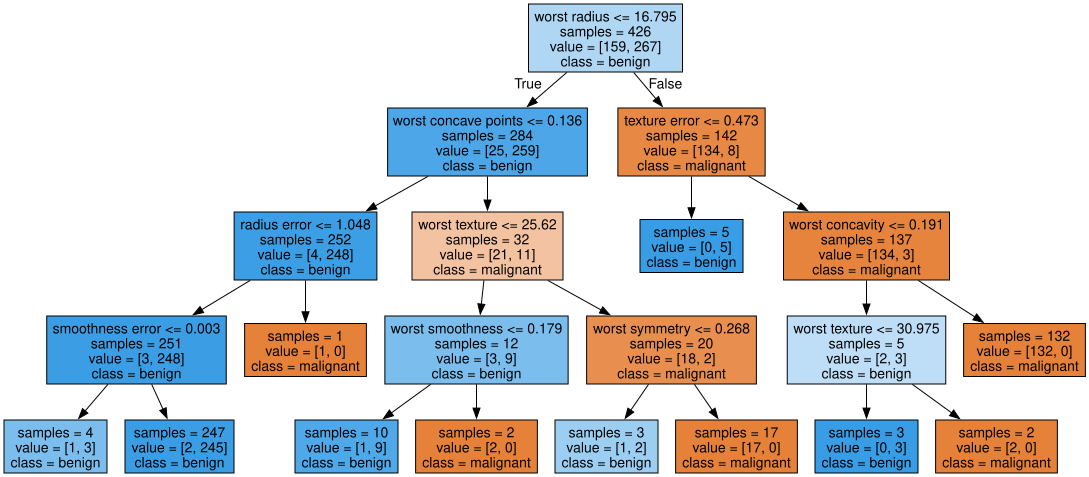

In [28]:
# 📌 標註：圖 2-27 —— 乳癌資料集決策樹結構圖 (max_depth=4)
import graphviz

with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

#### 📌 圖 2-27 決策樹結構圖解讀

樹狀圖的視覺化機能夠清楚呈現演算法的預測與決策邏輯，非常適合用來向非技術人員說明模型是如何做決定的。

然而，即便是 `max_depth=4` 的決策樹，結構看起來也已經相當龐大；若是在未剪枝、深度更高的情況下（例如深度為 10），樹狀圖將變得難以閱讀。

一種有效的解讀技巧是**追蹤大部分資料所流經的主幹路徑**：
* **`samples`**：代表目前節點中的樣本總數。
* **`value`**：代表該節點中各類別的樣本分佈情形（例如 `[惡性腫瘤, 良性腫瘤]`）。
* **`class`**：代表該節點目前占多數的判定類別。

---

##### 樹狀圖分割路徑拆解：

1. **根節點判定**：
   第一個測試條件為 `worst radius <= 16.795`（最差狀況下的腫瘤半徑）：
   * **條件成立（True，向左走）**：共有 284 個樣本流向左邊，包含 259 個良性與 25 個惡性腫瘤（`class = benign`）。
   * **條件不成立（False，向右走）**：共有 142 個樣本流向右邊，包含 134 個惡性與 8 個良性腫瘤（`class = malignant`）。

2. **追蹤右側主要路徑（惡性腫瘤側）**：
   在最初向右分支的 142 個樣本中，絕大多數（134 個）本身就是惡性腫瘤。後續的分支只是透過更細微的條件（如 `texture error`）將剩餘少數 8 個良性樣本排除掉。

3. **追蹤左側主要路徑（良性腫瘤側）**：
   在最初向左分支的 284 個樣本中，絕大多數（259 個）皆為良性腫瘤。大部分的良性樣本最終都集中在主要葉節點中，其餘子分支僅包含極少數的混合樣本。

### 2.2.4 樹狀圖中的特徵重要性（Feature Importances in Trees）

比起直接檢視整棵複雜的決策樹，最常使用的摘要屬性是**特徵重要性（Feature Importances）**。特徵重要性會為每個特徵計算權重評分，數值介於 0 與 1 之間：
* **`0`**：代表該特徵完全沒有被決策樹使用。
* **`1`**：代表該特徵能完美獨立完成預測。
* 所有特徵的重要性權重總和恆等於 1。

In [29]:
# 印出決策樹各特徵的數值重要性陣列
print(f"特徵重要性（Feature Importances）：\n{tree.feature_importances_}")

特徵重要性（Feature Importances）：
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


我們可以將陣列形式的特徵重要性以水平條型圖（Horizontal Bar Chart）進行視覺化展示，這類似於線性模型中展示特徵係數（Coefficients）的方式（📌 **對應圖 2-28**）：

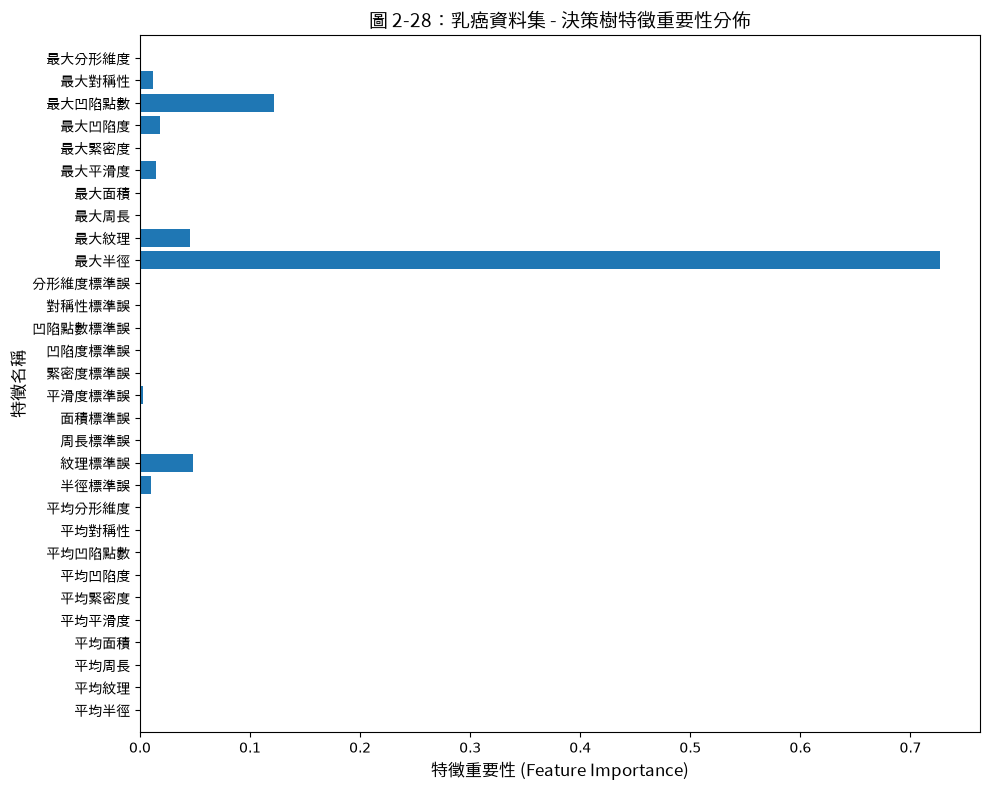

In [30]:
# 📌 標註：圖 2-28 —— 乳癌資料集決策樹特徵重要性分佈圖 (繁體中文標籤)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 載入中文字型
my_font = fm.FontProperties(fname="ChineseFont.ttf")

# 30 個乳癌特徵名稱的繁體中文翻譯對照
zh_feature_names = [
    "平均半徑", "平均紋理", "平均周長", "平均面積", "平均平滑度",
    "平均緊密度", "平均凹陷度", "平均凹陷點數", "平均對稱性", "平均分形維度",
    "半徑標準誤", "紋理標準誤", "周長標準誤", "面積標準誤", "平滑度標準誤",
    "緊密度標準誤", "凹陷度標準誤", "凹陷點數標準誤", "對稱性標準誤", "分形維度標準誤",
    "最大半徑", "最大紋理", "最大周長", "最大面積", "最大平滑度",
    "最大緊密度", "最大凹陷度", "最大凹陷點數", "最大對稱性", "最大分形維度"
]

def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.figure(figsize=(10, 8))
    plt.barh(range(n_features), model.feature_importances_, align="center")
    plt.yticks(np.arange(n_features), zh_feature_names, fontproperties=my_font)
    plt.xlabel("特徵重要性 (Feature Importance)", fontproperties=my_font, fontsize=12)
    plt.ylabel("特徵名稱", fontproperties=my_font, fontsize=12)
    plt.title("圖 2-28：乳癌資料集 - 決策樹特徵重要性分佈", fontproperties=my_font, fontsize=14)
    plt.ylim(-1, n_features)
    plt.tight_layout()

plot_feature_importances_cancer(tree)
plt.show()

#### 特徵重要性的特性與非單調關係（📌 對應圖 2-29 與 圖 2-30）

從前面乳癌資料集的特徵重要性圖表（圖 2-28）可以看出，「最大半徑（worst radius）」是迄今為止最重要的特徵。這證實了我們在分析樹狀圖時所觀察到的現象：根節點（第一層）僅靠這個特徵就已經能區分大部分的樣本。

然而，在使用**特徵重要性（Feature Importance）**時，需要注意以下兩大關鍵特性：

1. **重要性較低不代表沒有資訊量**：
   如果某個特徵的重要性數值很低甚至為 0，並不代表該特徵不重要，僅代表它「沒有被這棵決策樹選中」，可能因為有另一個特徵包含了與它高度相關的重疊資訊。

2. **重要性恆為正值，不代表方向性**：
   與線性模型（Linear Models）中的正負係數不同，決策樹的特徵重要性**始終為正值（$\ge 0$）**。它只告訴我們這個特徵「重不重要」，但**無法說明該特徵數值越高代表良性還是惡性**。

特徵與目標類別之間的關係往往不是單調增減的。如下圖 2-29 與 2-30 所示的二維合成資料集範例：

Feature importances: [0. 1.]


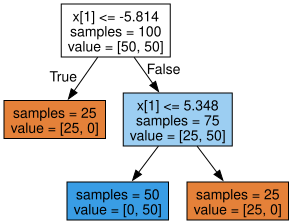

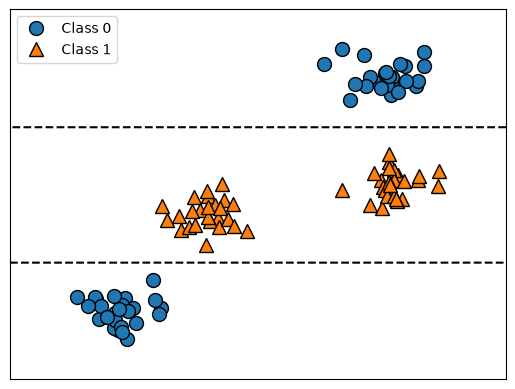

In [31]:
# 📌 標註：圖 2-29 與 圖 2-30 —— 非單調特徵關係與決策邊界圖
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)

### 2.2.5 決策樹迴歸與無法外推特性（Decision Trees for Regression & Extrapolation）

除了分類任務外，決策樹也可以套用於迴歸任務（透過 `sklearn.tree.DecisionTreeRegressor`）。

然而，**迴歸決策樹具有一項重大限制：它無法外推（Extrapolate），即無法預測訓練資料特徵範圍之外的未來趨勢**。

我們使用 `mglearn` 內建的 **RAM 記憶體歷史價格資料集（`ram_price.csv`）** 來驗證這個特性。該資料集紀錄了自 1957 年起 RAM 價格（美元/MB）隨時間的對數下降趨勢：

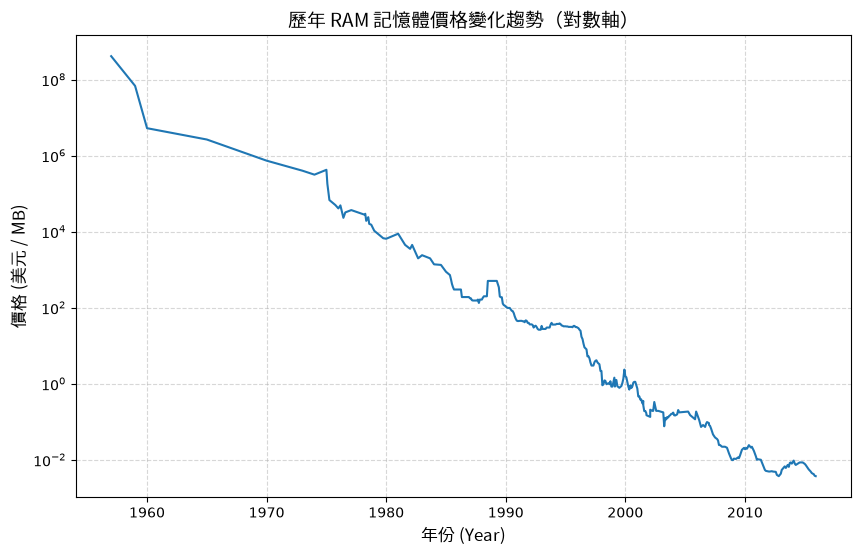

In [32]:
# 📌 標註：RAM 記憶體歷史價格對數變化趨勢圖
import os
import pandas as pd
import mglearn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 載入中文字型
my_font = fm.FontProperties(fname="ChineseFont.ttf")

# 使用 mglearn.datasets.DATA_PATH 自動取得 ram_price.csv 的真實路徑
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, "ram_price.csv"))

plt.figure(figsize=(10, 6))
plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel("年份 (Year)", fontproperties=my_font, fontsize=12)
plt.ylabel("價格 (美元 / MB)", fontproperties=my_font, fontsize=12)
plt.title("歷年 RAM 記憶體價格變化趨勢（對數軸）", fontproperties=my_font, fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

### 決策樹迴歸與線性迴歸的外推能力比較（📌 對應圖 2-31）

我們使用 2000 年之前的歷史 RAM 價格資料作為**訓練集（Training Set）**，訓練 `DecisionTreeRegressor` 與 `LinearRegression` 模型，並預測 2000 年之後（到 2016 年）的**測試集（Test Set）**價格趨勢。

在訓練前，我們先對價格目標進行**對數轉換（Log Transformation）**（對數轉換能將指數下降趨勢轉換為線性趨勢，便於模型學習）；訓練並預測完成後，再透過指數函式（`np.exp`）轉回原始價格。

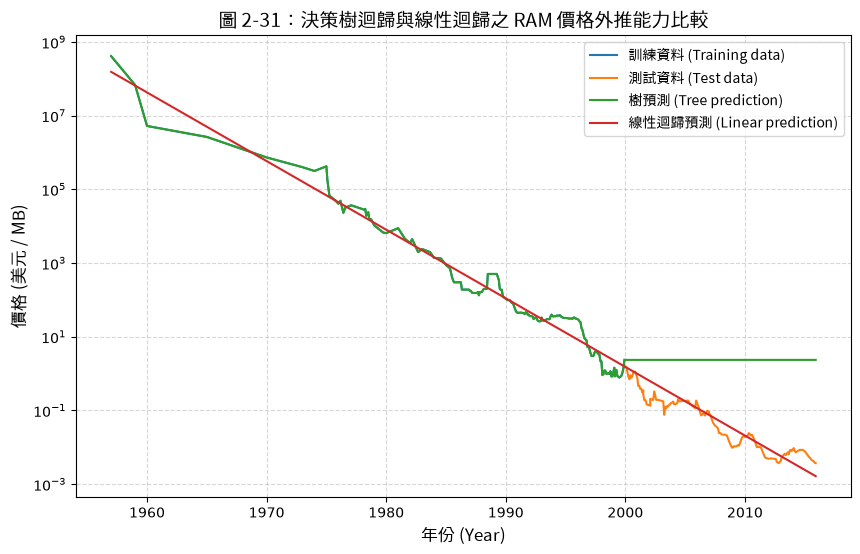

In [33]:
# 📌 標註：圖 2-31 —— 決策樹迴歸與線性迴歸在 RAM 價格預測上的外推能力比較圖
import os
import numpy as np
import pandas as pd
import mglearn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# 載入中文字型
my_font = fm.FontProperties(fname="ChineseFont.ttf")

# 讀取 RAM 價格歷史資料集
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, "ram_price.csv"))

# 使用 2000 年之前的歷史資料作為訓練集，2000 年之後作為測試集
data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

# 將日期轉換為 2D 陣列特徵 (X)
X_train = data_train.date.to_numpy()[:, np.newaxis]
# 對目標價格進行對數轉換 (y)
y_train = np.log(data_train.price)

# 訓練決策樹迴歸與線性迴歸模型
tree = DecisionTreeRegressor().fit(X_train, y_train)
linear_reg = LinearRegression().fit(X_train, y_train)

# 預測全部時間軸的價格
X_all = ram_prices.date.to_numpy()[:, np.newaxis]
pred_tree = tree.predict(X_all)
pred_lr = linear_reg.predict(X_all)

# 將預測結果轉回原始價格 (Exp 逆轉換)
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

# 繪製預測比較圖 (圖 2-31)
plt.figure(figsize=(10, 6))
plt.semilogy(data_train.date, data_train.price, label="訓練資料 (Training data)")
plt.semilogy(data_test.date, data_test.price, label="測試資料 (Test data)")
plt.semilogy(ram_prices.date, price_tree, label="樹預測 (Tree prediction)")
plt.semilogy(ram_prices.date, price_lr, label="線性迴歸預測 (Linear prediction)")
plt.xlabel("年份 (Year)", fontproperties=my_font, fontsize=12)
plt.ylabel("價格 (美元 / MB)", fontproperties=my_font, fontsize=12)
plt.title("圖 2-31：決策樹迴歸與線性迴歸之 RAM 價格外推能力比較", fontproperties=my_font, fontsize=14)
plt.legend(prop=my_font)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

#### 📌 圖 2-31 核心結論分析：

* **線性迴歸（Linear Regression）**：成功捕捉到了未來的對數線性趨勢，能夠持續預測 2000 年之後價格持續下降的方向（具備良好的**外推能力 Extrapolation**）。
* **決策樹迴歸（DecisionTreeRegressor）**：在 2000 年之前（訓練集內部）預測得非常精準；但在 2000 年之後（測試集外部），預測結果變為**水平直線（常數）**！
* **為什麼決策樹無法外推？**：
  決策樹是透過將特徵空間劃分為若干個區域（箱子）來進行預測的。當面對超出訓練資料範圍的輸入（例如 2000 年之後的年份）時，決策樹只能將該輸入歸類至最後一個劃分出來的葉節點中，並輸出該葉節點在訓練集中的平均值，因此無法預測新的未來趨勢。

### 2.2.6 決策樹的優缺點與參數調校總結（Strengths, Weaknesses, and Parameters）

#### 1. 主要控制參數（Complexity Control）
* 控制決策樹模型複雜度的主要機制是**預先剪枝（Pre-pruning）**參數。
* 在實務中，通常只需設定 **`max_depth`（最大深度）**、**`max_leaf_nodes`（最大葉節點數）** 或 **`min_samples_leaf`（葉節點最少樣本數）** 其中一種剪枝策略，就足以防止模型過擬合（Overfitting）。

---

#### 2. 決策樹的核心優勢（Strengths）
1. **易於視覺化與直觀解釋**：模型產生的 if/else 規則非常清晰，即使非專業技術人員也能輕鬆理解（特別是在樹深度較淺時）。
2. **無需資料特徵縮放（Scale Invariant）**：因為決策樹是針對各個特徵獨立進行切分測試，切分點完全不受數值範圍影響。因此**不需要對特徵進行標準化（Standardization）或正規化（Normalization）等預處理**。
3. **混合型特徵適應力強**：能完美處理包含不同數量級、或同時混合二元（Yes/No）與連續型數據的特徵。

---

#### 3. 決策樹的主要缺點（Weaknesses）
1. **極易過擬合與泛化能力較差**：即使採用了預先剪枝，單一決策樹依然容易對訓練集過擬合，導致泛化能力不佳。
2. **無法進行外推（Extrapolation）**：無法預測超出訓練資料範圍外的未來趨勢（如 RAM 價格範例所示）。

> 💡 **進階延伸**：為了克服單一決策樹容易過擬合的缺點，在現代機器學習實務中，通常會使用由多棵決策樹組合而成的**集成學習方法（Ensemble Methods）**，例如**隨機森林（Random Forest）**與**梯度提升樹（Gradient Boosted Trees）**來取代單一決策樹。